<a href="https://colab.research.google.com/github/josevalladares99/Parcial4_JoseValladares-2524322022/blob/main/Notebooks/Parcial4_correlacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd


In [2]:
url="https://raw.githubusercontent.com/josevalladares99/Parcial4_JoseValladares-2524322022/refs/heads/main/Archivos%20CSV/clave_B_correlacion.csv"

In [3]:
df=pd.read_csv(url) #Obtener primeras filas del dataset
df.head()

,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,B-C0001,37,818,9,43.76,8.24,0,5,8.56,456.85
1,B-C0002,29,693,5,30.73,9.25,0,3,16.91,215.38
2,B-C0003,26,552,7,42.77,7.24,3,6,29.86,293.80
3,B-C0004,31,980,9,67.02,7.61,1,6,17.09,603.80
4,B-C0005,37,965,7,51.24,9.40,0,7,12.21,521.52


In [5]:
numerical_cols = df.select_dtypes(include=['number'])
print(numerical_cols.columns.tolist())
print(numerical_cols.dtypes)

['edad', 'ingresos_mensuales', 'frecuencia_compra', 'ticket_promedio', 'satisfaccion', 'reclamos', 'uso_app', 'tiempo_respuesta', 'consumo_total']
edad                    int64
ingresos_mensuales      int64
frecuencia_compra       int64
ticket_promedio       float64
satisfaccion          float64
reclamos                int64
uso_app                 int64
tiempo_respuesta      float64
consumo_total         float64
dtype: object


In [6]:
#Valores nulos
print(df.isnull().sum())

Missing values per column:
cliente_id            0
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       1
satisfaccion          1
reclamos              0
uso_app               0
tiempo_respuesta      1
consumo_total         0
dtype: int64


In [7]:
print("Estadistica descriptiva :")
display(df.describe())

Descriptive statistics for numerical columns:


,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
count,226.000000,226.000000,226.000000,225.000000,225.000000,226.000000,226.000000,225.000000,226.000000
mean,35.716814,882.752212,7.172566,59.164622,7.556667,1.384956,5.185841,21.525511,439.469292
std,9.537732,263.237047,3.088523,15.233680,1.185569,1.435284,2.002437,6.233452,184.435972
min,18.000000,300.000000,1.000000,8.000000,3.070000,0.000000,0.000000,5.000000,67.440000
25%,29.000000,703.000000,6.000000,48.960000,6.960000,0.000000,4.000000,17.600000,335.435000
50%,36.000000,863.500000,7.000000,58.460000,7.650000,1.000000,5.000000,21.170000,430.665000
75%,42.000000,1078.750000,8.000000,69.580000,8.260000,2.000000,7.000000,24.780000,530.425000
max,65.000000,1503.000000,28.000000,111.380000,10.000000,9.000000,10.000000,43.800000,1558.440000


### 4. Detección de Valores Atípicos

In [9]:
numerical_cols_for_outliers = df.select_dtypes(include=['number']).columns.tolist()

# Excluir 'cliente_id' si se considera un identificador y no una variable numérica para análisis de distribución
if 'cliente_id' in numerical_cols_for_outliers:
    numerical_cols_for_outliers.remove('cliente_id')

print("Revisión de valores atípicos (Media ± 2 Desviaciones Estándar):\n")
for columna in numerical_cols_for_outliers:
    media = df[columna].mean()
    desviacion = df[columna].std()

    limite_inferior = media - 2 * desviacion
    limite_superior = media + 2 * desviacion

    atipicos = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    print(f"Columna: {columna}")
    print(f"  Límite Inferior: {limite_inferior:.2f}")
    print(f"  Límite Superior: {limite_superior:.2f}")
    print(f"  Cantidad de atípicos encontrados: {len(atipicos)}\n")

Revisión de valores atípicos (Media ± 2 Desviaciones Estándar):

Columna: edad
  Límite Inferior: 16.64
  Límite Superior: 54.79
  Cantidad de atípicos encontrados: 3

Columna: ingresos_mensuales
  Límite Inferior: 356.28
  Límite Superior: 1409.23
  Cantidad de atípicos encontrados: 9

Columna: frecuencia_compra
  Límite Inferior: 1.00
  Límite Superior: 13.35
  Cantidad de atípicos encontrados: 3

Columna: ticket_promedio
  Límite Inferior: 28.70
  Límite Superior: 89.63
  Cantidad de atípicos encontrados: 10

Columna: satisfaccion
  Límite Inferior: 5.19
  Límite Superior: 9.93
  Cantidad de atípicos encontrados: 10

Columna: reclamos
  Límite Inferior: -1.49
  Límite Superior: 4.26
  Cantidad de atípicos encontrados: 9

Columna: uso_app
  Límite Inferior: 1.18
  Límite Superior: 9.19
  Cantidad de atípicos encontrados: 8

Columna: tiempo_respuesta
  Límite Inferior: 9.06
  Límite Superior: 33.99
  Cantidad de atípicos encontrados: 11

Columna: consumo_total
  Límite Inferior: 70.60

### 5. Matriz de Correlación



In [10]:
matriz_correlacion = df.corr(numeric_only=True)
display(matriz_correlacion.round(3))

,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
edad,1.000,-0.056,0.006,0.134,0.079,-0.066,-0.031,-0.081,0.073
ingresos_mensuales,-0.056,1.000,0.154,0.605,-0.003,0.009,0.059,-0.029,0.400
frecuencia_compra,0.006,0.154,1.000,0.114,0.262,-0.129,0.522,-0.232,0.870
ticket_promedio,0.134,0.605,0.114,1.000,-0.003,0.005,0.026,-0.045,0.507
satisfaccion,0.079,-0.003,0.262,-0.003,1.000,-0.771,0.246,-0.630,0.291
reclamos,-0.066,0.009,-0.129,0.005,-0.771,1.000,0.024,0.564,-0.158
uso_app,-0.031,0.059,0.522,0.026,0.246,0.024,1.000,-0.173,0.524
tiempo_respuesta,-0.081,-0.029,-0.232,-0.045,-0.630,0.564,-0.173,1.000,-0.296
consumo_total,0.073,0.400,0.870,0.507,0.291,-0.158,0.524,-0.296,1.000


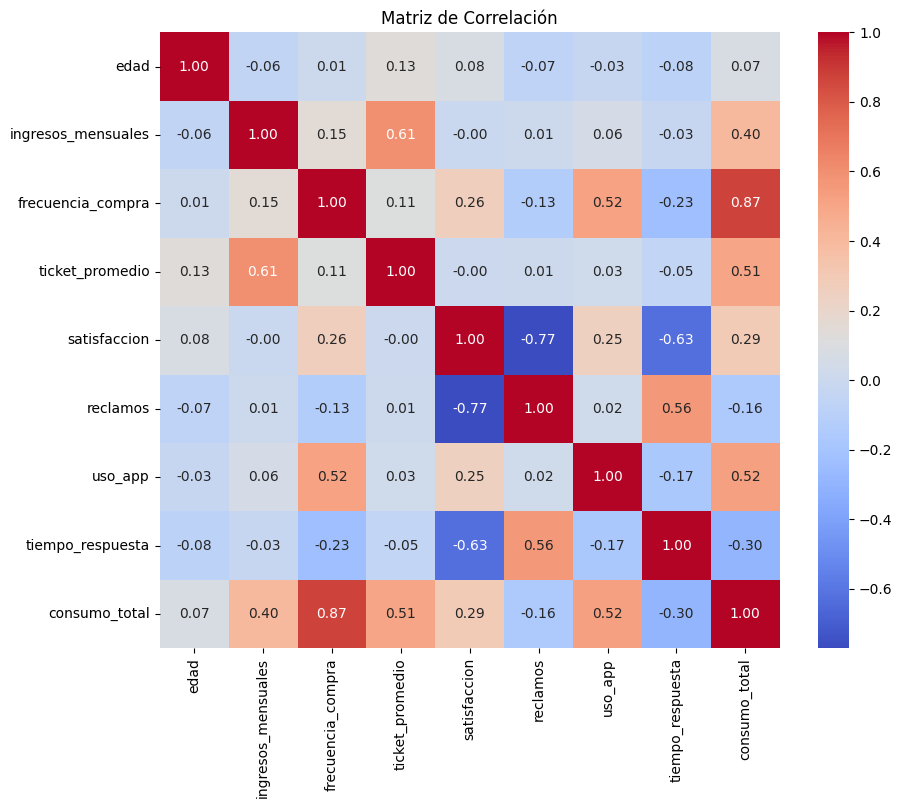

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurarse de que `df_numeric` esté definido con las columnas numéricas
df_numeric = df.select_dtypes(include=['number'])
matriz = df_numeric.corr()

plt.figure(figsize=(10,8))
sns.heatmap(matriz, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

### 7. Identificación de las Correlaciones Positivas Más Importantes

Basándonos en la matriz de correlación y el mapa de calor, vamos a extraer las correlaciones positivas más fuertes. Esto nos ayudará a entender qué variables tienden a aumentar o disminuir juntas de manera más significativa.

In [13]:
import numpy as np

# Obtener solo las correlaciones del triángulo superior (sin duplicados y sin la diagonal principal)
upper_tri = matriz_correlacion.where(np.triu(np.ones(matriz_correlacion.shape), k=1).astype(bool))

# Apilar para obtener una Serie y filtrar las correlaciones positivas
positive_correlations = upper_tri.stack().sort_values(ascending=False)

print("Las correlaciones positivas más importantes son:\n")
# Mostrar las 5 correlaciones positivas más fuertes
for (var1, var2), corr_value in positive_correlations.head(5).items():
    print(f"  '{var1}' con '{var2}': {corr_value:.3f}")

Las correlaciones positivas más importantes son:

  'frecuencia_compra' con 'consumo_total': 0.870
  'ingresos_mensuales' con 'ticket_promedio': 0.605
  'reclamos' con 'tiempo_respuesta': 0.564
  'uso_app' con 'consumo_total': 0.524
  'frecuencia_compra' con 'uso_app': 0.522


### 8. Identificación de las Correlaciones Negativas Más Importantes



In [14]:
import numpy as np

# Obtener solo las correlaciones del triángulo superior (sin duplicados y sin la diagonal principal)
upper_tri_neg = matriz_correlacion.where(np.triu(np.ones(matriz_correlacion.shape), k=1).astype(bool))

# Apilar para obtener una Serie y filtrar las correlaciones negativas
negative_correlations = upper_tri_neg.stack().sort_values(ascending=True)

print("Las correlaciones negativas más importantes son:\n")
# Mostrar las 5 correlaciones negativas más fuertes
for (var1, var2), corr_value in negative_correlations.head(5).items():
    print(f"  '{var1}' con '{var2}': {corr_value:.3f}")

Las correlaciones negativas más importantes son:

  'satisfaccion' con 'reclamos': -0.771
  'satisfaccion' con 'tiempo_respuesta': -0.630
  'tiempo_respuesta' con 'consumo_total': -0.296
  'frecuencia_compra' con 'tiempo_respuesta': -0.232
  'uso_app' con 'tiempo_respuesta': -0.173
